<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/03_computer_vision/07_fine_tuning_pretrained_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fine-Tuning Pretrained Models

Transfer Learning uses a pre-trained model as a fixed feature extractor by freezing all its layers.

Fine-Tuning goes one step further by unfreezing some of the deeper layers and allowing them to update during training. This helps the model adapt the learned features to a new dataset while still retaining the valuable knowledge gained from large datasets such as ImageNet.

Fine-tuning often leads to better accuracy, especially when the new dataset is sufficiently large and similar to the original training data. To avoid damaging the pre-trained weights, a very small learning rate is typically used.

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
base_model.trainable = False

In [4]:
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [5]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [6]:
trainable_count = 0

for layer in base_model.layers:
    if layer.trainable:
        trainable_count += 1

print("Trainable Layers:", trainable_count)

Trainable Layers: 30


In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [8]:
import pandas as pd

comparison = pd.DataFrame({

    "Transfer Learning":[
        "Base model frozen",
        "Fast training",
        "Less computation",
        "Good for small datasets"
    ],

    "Fine-Tuning":[
        "Some layers unfrozen",
        "Better accuracy",
        "More computation",
        "Adapts learned features"
    ]

})

comparison

,Transfer Learning,Fine-Tuning
0,Base model frozen,Some layers unfrozen
1,Fast training,Better accuracy
2,Less computation,More computation
3,Good for small datasets,Adapts learned features


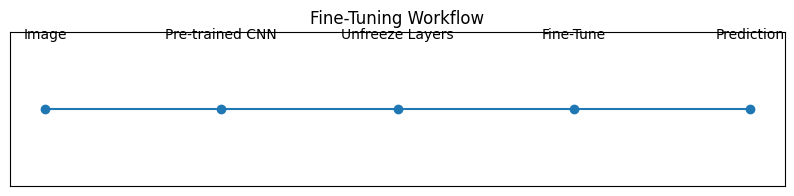

In [9]:
steps = [
    "Image",
    "Pre-trained CNN",
    "Unfreeze Layers",
    "Fine-Tune",
    "Prediction"
]

plt.figure(figsize=(10,2))

plt.plot(range(len(steps)), [1]*len(steps), marker="o")

for i, step in enumerate(steps):
    plt.text(i, 1.05, step, ha="center")

plt.xticks([])
plt.yticks([])

plt.title("Fine-Tuning Workflow")

plt.show()